In [ ]:
import pandas as pd

retail = pd.read_csv('online_retail_II.csv', parse_dates=['InvoiceDate'])
retail.set_index('InvoiceDate', inplace=True)

In [2]:
retail.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,1067371.0,9.938898,172.705794,-80995.00,1.00,3.0,10.00,80995.0
Price,1067371.0,4.649388,123.553059,-53594.36,1.25,2.1,4.15,38970.0
Customer ID,824364.0,15324.638504,1697.464450,12346.00,13975.00,15255.0,16797.00,18287.0


In [3]:
retail.describe(include='object').T

,count,unique,top,freq
Invoice,1067371,53628,537434,1350
StockCode,1067371,5305,85123A,5829
Description,1062989,5698,WHITE HANGING HEART T-LIGHT HOLDER,5918
Country,1067371,43,United Kingdom,981330


In [4]:
retail.isnull().sum() / len(retail) * 100

Invoice         0.000000
StockCode       0.000000
Description     0.410541
Quantity        0.000000
Price           0.000000
Customer ID    22.766873
Country         0.000000
dtype: float64

In [5]:
retail.dropna(inplace=True)
retail.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
Price          0
Customer ID    0
Country        0
dtype: int64

In [6]:
duplicate = retail[retail.duplicated(keep=False)]
duplicate.sort_values(by=['Invoice', 'StockCode', 'Description', 'Customer ID', 'Quantity'])

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country
InvoiceDate,,,,,,,
2009-12-01 11:34:00,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,1.95,16329.0,United Kingdom
2009-12-01 11:34:00,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,1.95,16329.0,United Kingdom
2009-12-01 11:34:00,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,3.75,16329.0,United Kingdom
2009-12-01 11:34:00,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,3.75,16329.0,United Kingdom
2009-12-01 11:34:00,489517,21912,VINTAGE SNAKES & LADDERS,1,3.75,16329.0,United Kingdom
...,...,...,...,...,...,...,...
2011-11-04 13:25:00,C574510,22360,GLASS JAR ENGLISH CONFECTIONERY,-1,2.95,15110.0,United Kingdom
2011-11-13 11:38:00,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,0.55,17838.0,United Kingdom
2011-11-13 11:38:00,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,0.55,17838.0,United Kingdom


In [7]:
retail.drop_duplicates(inplace=True)
retail.duplicated().sum()

np.int64(0)

In [8]:
import numpy as np

retail['Transaction_Status'] = np.where(retail['Invoice'].astype(str).str.startswith('C'), 'Cancelled', 'Completed')

cancelled_transaction = retail[retail['Transaction_Status'] == 'Cancelled']
cancelled_transaction.loc[:, ['Quantity', 'Price']].describe()

,Quantity,Price
count,18390.000000,18390.000000
mean,-25.719195,24.240567
std,825.979381,428.241509
min,-80995.000000,0.010000
25%,-6.000000,1.450000
50%,-2.000000,2.950000
75%,-1.000000,5.950000
max,-1.000000,38970.000000


In [9]:
print(f'Cancelled Transactions: {cancelled_transaction.shape[0] / retail.shape[0] * 100:.2f}%')

Cancelled Transactions: 2.30%


Unique Stock Codes: 4646


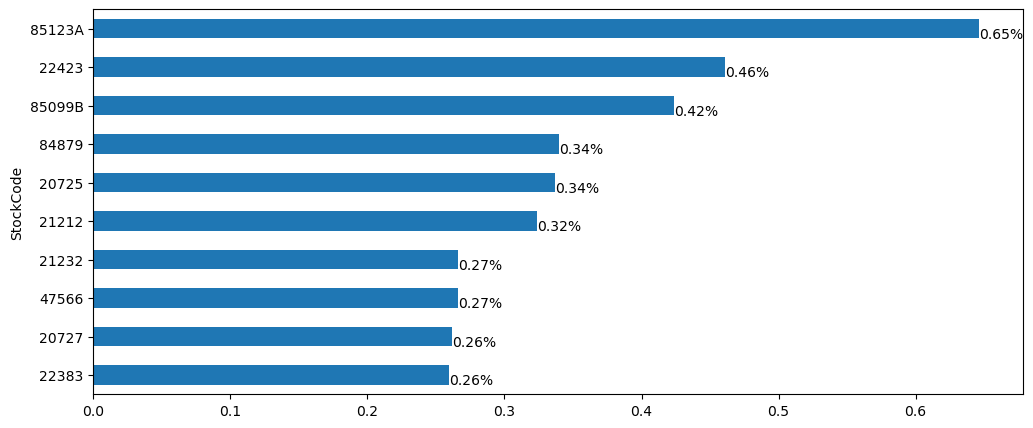

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

unique_stock_codes = retail['StockCode'].nunique()
print(f'Unique Stock Codes: {unique_stock_codes}')

top_10_stock_codes = retail['StockCode'].value_counts(normalize=True).head(10) * 100

plt.figure(figsize=(12, 5))
top_10_stock_codes.plot(kind='barh')

for index, value in enumerate(top_10_stock_codes):
    plt.text(value, index+0.25, f'{value:.2f}%')

plt.gca().invert_yaxis()
plt.show()

In [11]:
alpha_only = retail[retail['StockCode'].str.isalpha()]
print(f'Anomalies: {len(alpha_only) / len(retail) * 100:.2f}%')

Anomalies: 0.42%


In [12]:
retail = retail[~retail['StockCode'].str.isalpha()]

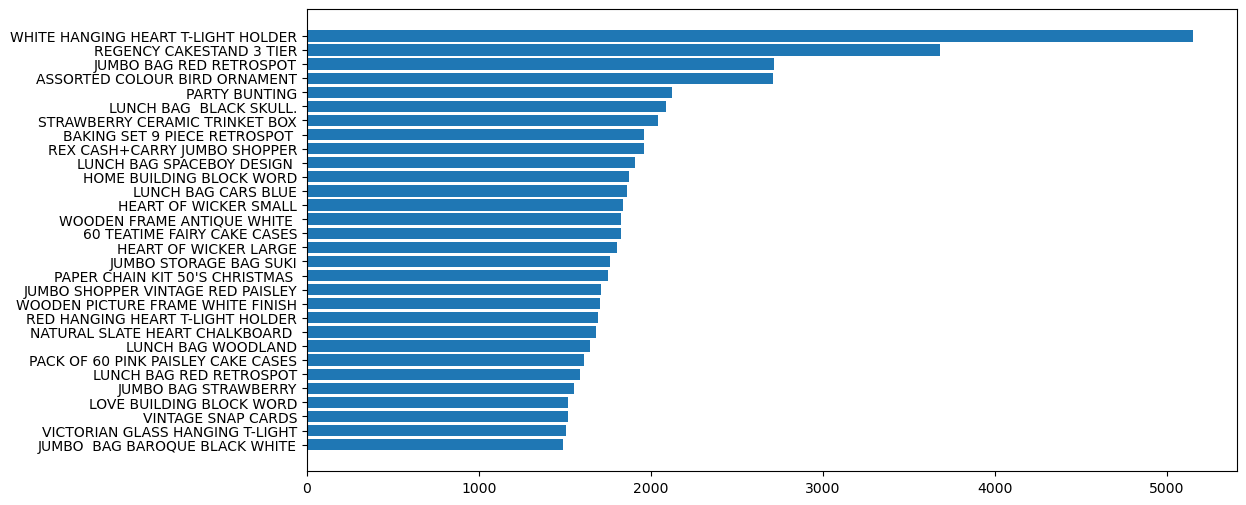

In [13]:
description_counts = retail['Description'].value_counts()
top_30_descriptions = description_counts[:30]

plt.figure(figsize=(12,6))
plt.barh(top_30_descriptions.index[::-1], top_30_descriptions.values[::-1])
plt.show()

In [14]:
lowercase_descriptions = retail['Description'].unique()
lowercase_descriptions = [desc for desc in lowercase_descriptions if any(char.islower() for char in desc)]

print("The unique descriptions containing lowercase characters are:")
print("-"*60)
for desc in lowercase_descriptions:
    print(desc)

The unique descriptions containing lowercase characters are:
------------------------------------------------------------
BAG 500g SWIRLY MARBLES
POLYESTER FILLER PAD 40x40cm
POLYESTER FILLER PAD 60x40cm
POLYESTER FILLER PAD 65CMx65CM
POLYESTER FILLER PAD 45x45cm
BAG 125g SWIRLY MARBLES
ESSENTIAL BALM 3.5g TIN IN ENVELOPE
FOLK ART GREETING CARD,pack/12
BAG 250g SWIRLY MARBLES
POLYESTER FILLER PAD 30CMx30CM
 Bank Charges
This is a test product.
POLYESTER FILLER PAD 45x30cm
Bank Charges
 SET Of 6 SOLDIER SKITTLES
THE KING GIFT BAG 25x24x12cm
Adjustment by Peter on Jun 25 2010 
FRENCH BLUE METAL DOOR SIGN, No
NUMBER TILE COTTAGE GARDEN, No
NUMBER TILE VINTAGE FONT, No 
NUMBER TILE VINTAGE FONT No 
FRENCH BLUE METAL DOOR SIGN No
NUMBER TILE COTTAGE GARDEN No
3 TRADITIONAl BISCUIT CUTTERS  SET
FLOWERS HANDBAG blue and orange
Next Day Carriage
High Resolution Image


In [15]:
first_uppercase = ~retail['Description'].str.contains(r'\b[A-Z]+\b')
retail[first_uppercase]

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,Transaction_Status
InvoiceDate,,,,,,,,
2009-12-08 14:08:00,C490943,BANK CHARGES,Bank Charges,-1,15.0,16703.0,United Kingdom,Cancelled
2009-12-08 14:29:00,490948,BANK CHARGES,Bank Charges,1,15.0,16805.0,United Kingdom,Completed
2009-12-14 08:34:00,491725,TEST001,This is a test product.,10,4.5,12346.0,United Kingdom,Completed
2009-12-14 11:00:00,491742,TEST001,This is a test product.,5,4.5,12346.0,United Kingdom,Completed
2009-12-14 11:02:00,491744,TEST001,This is a test product.,5,4.5,12346.0,United Kingdom,Completed
...,...,...,...,...,...,...,...,...
2011-12-05 12:11:00,580630,23444,Next Day Carriage,1,15.0,12913.0,United Kingdom,Completed
2011-12-07 12:45:00,581127,BANK CHARGES,Bank Charges,1,15.0,16271.0,United Kingdom,Completed
2011-12-07 12:55:00,581132,23444,Next Day Carriage,1,15.0,17590.0,United Kingdom,Completed


In [16]:
retail = retail[~first_uppercase]

In [17]:
retail[['Price', 'Quantity']].describe()

,Price,Quantity
count,794394.000000,794394.000000
mean,2.985104,12.650315
std,4.554998,192.058331
min,0.000000,-80995.000000
25%,1.250000,2.000000
50%,1.950000,5.000000
75%,3.750000,12.000000
max,649.500000,80995.000000


In [18]:
retail[retail['Price'] == 0]['Quantity'].describe()

count       60.000000
mean       245.583333
std       1616.970743
min          1.000000
25%          2.000000
50%          7.000000
75%         21.000000
max      12540.000000
Name: Quantity, dtype: float64

In [19]:
retail = retail[retail['Price'] > 0]

In [20]:
retail.reset_index(inplace=True)

In [21]:
retail['InvoiceDay'] = retail['InvoiceDate'].dt.date
most_recent_date = retail['InvoiceDay'].max()

customer_data = retail.groupby('Customer ID')['InvoiceDay'].max().reset_index()
customer_data['InvoiceDay'] = pd.to_datetime(customer_data['InvoiceDay'])

most_recent_date = pd.to_datetime(most_recent_date)
customer_data['Days_Since_Last_Purchase'] = (most_recent_date - customer_data['InvoiceDay']).dt.days
customer_data.drop(columns=['InvoiceDay'], inplace=True)

In [22]:
customer_data

,Customer ID,Days_Since_Last_Purchase
0,12346.0,325
1,12347.0,2
2,12348.0,75
3,12349.0,18
4,12350.0,310
...,...,...
5871,18283.0,3
5872,18284.0,429
5873,18285.0,660
5874,18286.0,476


In [23]:
total_transaction = retail.groupby('Customer ID')['Invoice'].nunique().reset_index()
total_transaction.rename(columns={'Invoice':'Total_Transaction'}, inplace=True)

total_product_purchased = retail.groupby('Customer ID')['Quantity'].sum().reset_index()
total_product_purchased.rename(columns={'Quantity':'Total_Product_Purchased'}, inplace=True)


customer_data = pd.merge(customer_data, total_transaction, on='Customer ID')
customer_data = pd.merge(customer_data, total_product_purchased, on='Customer ID')

In [24]:
customer_data

,Customer ID,Days_Since_Last_Purchase,Total_Transaction,Total_Product_Purchased
0,12346.0,325,4,24
1,12347.0,2,8,2967
2,12348.0,75,5,2704
3,12349.0,18,4,1616
4,12350.0,310,1,196
...,...,...,...,...
5871,18283.0,3,22,1677
5872,18284.0,429,2,493
5873,18285.0,660,1,145
5874,18286.0,476,3,592


In [25]:
retail['Total_Spend'] = retail['Price'] * retail['Quantity']
total_spend = retail.groupby('Customer ID')['Total_Spend'].sum().reset_index()

average_transaction_value = total_spend.merge(total_transaction, on='Customer ID')
average_transaction_value['Average_Transaction_Value'] = average_transaction_value['Total_Spend'] / average_transaction_value['Total_Transaction']

customer_data = pd.merge(customer_data, total_spend, on='Customer ID')
customer_data = pd.merge(customer_data, average_transaction_value[['Customer ID', 'Average_Transaction_Value']], on='Customer ID')

In [26]:
customer_data

,Customer ID,Days_Since_Last_Purchase,Total_Transaction,Total_Product_Purchased,Total_Spend,Average_Transaction_Value
0,12346.0,325,4,24,169.36,42.340000
1,12347.0,2,8,2967,4921.53,615.191250
2,12348.0,75,5,2704,1658.40,331.680000
3,12349.0,18,4,1616,3654.54,913.635000
4,12350.0,310,1,196,294.40,294.400000
...,...,...,...,...,...,...
5871,18283.0,3,22,1677,2658.95,120.861364
5872,18284.0,429,2,493,436.68,218.340000
5873,18285.0,660,1,145,427.00,427.000000
5874,18286.0,476,3,592,1188.43,396.143333


In [27]:
unique_product_purchased = retail.groupby('Customer ID')['StockCode'].nunique().reset_index()
unique_product_purchased.rename(columns={'StockCode':'Unique_Product_Purchased'}, inplace=True)

customer_data = pd.merge(customer_data, unique_product_purchased, on='Customer ID')

In [28]:
customer_data

,Customer ID,Days_Since_Last_Purchase,Total_Transaction,Total_Product_Purchased,Total_Spend,Average_Transaction_Value,Unique_Product_Purchased
0,12346.0,325,4,24,169.36,42.340000,25
1,12347.0,2,8,2967,4921.53,615.191250,126
2,12348.0,75,5,2704,1658.40,331.680000,24
3,12349.0,18,4,1616,3654.54,913.635000,138
4,12350.0,310,1,196,294.40,294.400000,16
...,...,...,...,...,...,...,...
5871,18283.0,3,22,1677,2658.95,120.861364,351
5872,18284.0,429,2,493,436.68,218.340000,28
5873,18285.0,660,1,145,427.00,427.000000,12
5874,18286.0,476,3,592,1188.43,396.143333,67


In [29]:
# Extract day of week and hour from InvoiceDate
retail['Favorite_Week'] = retail['InvoiceDate'].dt.dayofweek
retail['Favorite_Hour'] = retail['InvoiceDate'].dt.hour

# Calculate the average number of days between consecutive purchases
days_between_purchases = retail.groupby('Customer ID')['InvoiceDay'].apply(lambda x: (x.diff().dropna()).apply(lambda y: y.days))
average_days_between_purchases = days_between_purchases.groupby('Customer ID').mean().reset_index()
average_days_between_purchases.rename(columns={'InvoiceDay': 'Average_Days_Between_Purchases'}, inplace=True)

# Find the favorite shopping day of the week
favorite_shopping_day = retail.groupby(['Customer ID', 'Favorite_Week']).size().reset_index(name='Count')
favorite_shopping_day = favorite_shopping_day.loc[favorite_shopping_day.groupby('Customer ID')['Count'].idxmax()][['Customer ID', 'Favorite_Week']]

# Find the favorite shopping hour of the day
favorite_shopping_hour = retail.groupby(['Customer ID', 'Favorite_Hour']).size().reset_index(name='Count')
favorite_shopping_hour = favorite_shopping_hour.loc[favorite_shopping_hour.groupby('Customer ID')['Count'].idxmax()][['Customer ID', 'Favorite_Hour']]

# Merge the new features into the customer_data dataframe
customer_data = pd.merge(customer_data, average_days_between_purchases, on='Customer ID')
customer_data = pd.merge(customer_data, favorite_shopping_day, on='Customer ID')
customer_data = pd.merge(customer_data, favorite_shopping_hour, on='Customer ID')

# Display the first few rows of the customer_data dataframe
customer_data.head()

/tmp/ipykernel_13767/4038975876.py:6: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  days_between_purchases = retail.groupby('Customer ID')['InvoiceDay'].apply(lambda x: (x.diff().dropna()).apply(lambda y: y.days))


,Customer ID,Days_Since_Last_Purchase,Total_Transaction,Total_Product_Purchased,Total_Spend,Average_Transaction_Value,Unique_Product_Purchased,Average_Days_Between_Purchases,Favorite_Week,Favorite_Hour
0,12346.0,325,4,24,169.36,42.34000,25,12.880000,0,13
1,12347.0,2,8,2967,4921.53,615.19125,126,1.819005,1,14
2,12348.0,75,5,2704,1658.40,331.68000,24,8.066667,0,14
3,12349.0,18,4,1616,3654.54,913.63500,138,4.073864,3,9
4,12350.0,310,1,196,294.40,294.40000,16,0.000000,2,16


In [30]:
retail['Country'].value_counts(normalize=True).head() * 100

Country
United Kingdom    89.968074
Germany            2.096473
EIRE               2.007594
France             1.686822
Netherlands        0.631472
Name: proportion, dtype: float64

In [31]:
customer_country = retail.groupby(['Customer ID', 'Country']).size().reset_index(name='Number_of_Transactions')

customer_main_country = customer_country.sort_values('Number_of_Transactions', ascending=False).drop_duplicates('Customer ID')
customer_main_country['Is_UK'] = customer_main_country['Country'].apply(lambda x: 1 if x == 'United Kingdom' else 0)

customer_data = pd.merge(customer_data, customer_main_country[['Customer ID', 'Is_UK']], on='Customer ID', how='left')

customer_data.head()

,Customer ID,Days_Since_Last_Purchase,Total_Transaction,Total_Product_Purchased,Total_Spend,Average_Transaction_Value,Unique_Product_Purchased,Average_Days_Between_Purchases,Favorite_Week,Favorite_Hour,Is_UK
0,12346.0,325,4,24,169.36,42.34000,25,12.880000,0,13,1
1,12347.0,2,8,2967,4921.53,615.19125,126,1.819005,1,14,0
2,12348.0,75,5,2704,1658.40,331.68000,24,8.066667,0,14,0
3,12349.0,18,4,1616,3654.54,913.63500,138,4.073864,3,9,0
4,12350.0,310,1,196,294.40,294.40000,16,0.000000,2,16,0


In [32]:
customer_data['Is_UK'].value_counts()

Is_UK
1    5254
0     514
Name: count, dtype: int64

In [33]:
total_transactions = retail.groupby('Customer ID')['Invoice'].nunique().reset_index()

cancelled_transaction = retail[retail['Transaction_Status'] == 'Cancelled']
cancellation_frequency = cancelled_transaction.groupby('Customer ID')['Invoice'].nunique().reset_index()
cancellation_frequency.rename(columns={'Invoice':'Cancellation_Frequency'}, inplace=True)

customer_data = pd.merge(customer_data, cancellation_frequency, on='Customer ID', how='left')
customer_data['Cancellation_Frequency'].fillna(0, inplace=True)

customer_data['Cancellation_Rate'] = customer_data['Cancellation_Frequency'] / total_transactions['Invoice']

customer_data.head()

/tmp/ipykernel_13767/459220683.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customer_data['Cancellation_Frequency'].fillna(0, inplace=True)


,Customer ID,Days_Since_Last_Purchase,Total_Transaction,Total_Product_Purchased,Total_Spend,Average_Transaction_Value,Unique_Product_Purchased,Average_Days_Between_Purchases,Favorite_Week,Favorite_Hour,Is_UK,Cancellation_Frequency,Cancellation_Rate
0,12346.0,325,4,24,169.36,42.34000,25,12.880000,0,13,1,1.0,0.25
1,12347.0,2,8,2967,4921.53,615.19125,126,1.819005,1,14,0,0.0,0.00
2,12348.0,75,5,2704,1658.40,331.68000,24,8.066667,0,14,0,0.0,0.00
3,12349.0,18,4,1616,3654.54,913.63500,138,4.073864,3,9,0,1.0,0.25
4,12350.0,310,1,196,294.40,294.40000,16,0.000000,2,16,0,0.0,0.00


In [34]:
from scipy.stats import linregress

retail['Year'] = retail['InvoiceDate'].dt.year
retail['Month'] = retail['InvoiceDate'].dt.month

monthly_spending = retail.groupby(['Customer ID', 'Year', 'Month'])['Total_Spend'].sum().reset_index()

seasonal_buying_patterns = monthly_spending.groupby('Customer ID')['Total_Spend'].agg(['mean', 'std']).reset_index()
seasonal_buying_patterns.rename(columns={'mean': 'Monthly_Spending_Mean', 'std':'Monthly_Spending_Std'}, inplace=True)
seasonal_buying_patterns['Monthly_Spending_Std'].fillna(0, inplace=True)

def calculate_trend(spend_data):
    if len(spend_data) > 1:
        x = np.arange(len(spend_data))
        slope, _, _, _, _ = linregress(x, spend_data)
        return slope
    else:
        return 0

spending_trends = monthly_spending.groupby('Customer ID')['Total_Spend'].apply(calculate_trend).reset_index()
spending_trends.rename(columns={'Total_Spend':'Spending_Trend'}, inplace=True)

customer_data = pd.merge(customer_data, seasonal_buying_patterns, on='Customer ID')
customer_data = pd.merge(customer_data, spending_trends, on='Customer ID')

customer_data.head()

/tmp/ipykernel_13767/2555810732.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  seasonal_buying_patterns['Monthly_Spending_Std'].fillna(0, inplace=True)


,Customer ID,Days_Since_Last_Purchase,Total_Transaction,Total_Product_Purchased,Total_Spend,Average_Transaction_Value,Unique_Product_Purchased,Average_Days_Between_Purchases,Favorite_Week,Favorite_Hour,Is_UK,Cancellation_Frequency,Cancellation_Rate,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend
0,12346.0,325,4,24,169.36,42.34000,25,12.880000,0,13,1,1.0,0.25,56.453333,75.574143,-13.525000
1,12347.0,2,8,2967,4921.53,615.19125,126,1.819005,1,14,0,0.0,0.00,615.191250,315.773658,3.339405
2,12348.0,75,5,2704,1658.40,331.68000,24,8.066667,0,14,0,0.0,0.00,331.680000,187.058966,-22.812000
3,12349.0,18,4,1616,3654.54,913.63500,138,4.073864,3,9,0,1.0,0.25,913.635000,647.144349,452.920000
4,12350.0,310,1,196,294.40,294.40000,16,0.000000,2,16,0,0.0,0.00,294.400000,0.000000,0.000000


In [35]:
customer_data['Customer ID'] = customer_data['Customer ID'].astype(str)
customer_data = customer_data.convert_dtypes()

customer_data

,Customer ID,Days_Since_Last_Purchase,Total_Transaction,Total_Product_Purchased,Total_Spend,Average_Transaction_Value,Unique_Product_Purchased,Average_Days_Between_Purchases,Favorite_Week,Favorite_Hour,Is_UK,Cancellation_Frequency,Cancellation_Rate,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend
0,12346.0,325,4,24,169.36,42.34,25,12.88,0,13,1,1,0.25,56.453333,75.574143,-13.525
1,12347.0,2,8,2967,4921.53,615.19125,126,1.819005,1,14,0,0,0.0,615.19125,315.773658,3.339405
2,12348.0,75,5,2704,1658.4,331.68,24,8.066667,0,14,0,0,0.0,331.68,187.058966,-22.812
3,12349.0,18,4,1616,3654.54,913.635,138,4.073864,3,9,0,1,0.25,913.635,647.144349,452.92
4,12350.0,310,1,196,294.4,294.4,16,0.0,2,16,0,0,0.0,294.4,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5763,18283.0,3,22,1677,2658.95,120.861364,351,0.700535,3,13,1,0,0.0,189.925,144.03184,12.74622
5764,18284.0,429,2,493,436.68,218.34,28,0.071429,0,11,1,1,0.5,436.68,0.0,0.0
5765,18285.0,660,1,145,427.0,427.0,12,0.0,2,10,1,0,0.0,427.0,0.0,0.0
5766,18286.0,476,3,592,1188.43,396.143333,67,3.57971,4,11,1,1,0.066667,396.143333,474.282084,185.265


In [36]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5768 entries, 0 to 5767
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Customer ID                     5768 non-null   string 
 1   Days_Since_Last_Purchase        5768 non-null   Int64  
 2   Total_Transaction               5768 non-null   Int64  
 3   Total_Product_Purchased         5768 non-null   Int64  
 4   Total_Spend                     5768 non-null   Float64
 5   Average_Transaction_Value       5768 non-null   Float64
 6   Unique_Product_Purchased        5768 non-null   Int64  
 7   Average_Days_Between_Purchases  5768 non-null   Float64
 8   Favorite_Week                   5768 non-null   Int32  
 9   Favorite_Hour                   5768 non-null   Int32  
 10  Is_UK                           5768 non-null   Int64  
 11  Cancellation_Frequency          5768 non-null   Int64  
 12  Cancellation_Rate               57

In [37]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.05, random_state=0)

customer_data['Outlier_Scores'] = model.fit_predict(customer_data.iloc[:, 1:].to_numpy())
customer_data['Is_Outlier'] = [1 if x == -1 else 0 for x in customer_data['Outlier_Scores']]
customer_data.head()

,Customer ID,Days_Since_Last_Purchase,Total_Transaction,Total_Product_Purchased,Total_Spend,Average_Transaction_Value,Unique_Product_Purchased,Average_Days_Between_Purchases,Favorite_Week,Favorite_Hour,Is_UK,Cancellation_Frequency,Cancellation_Rate,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend,Outlier_Scores,Is_Outlier
0,12346.0,325,4,24,169.36,42.34,25,12.88,0,13,1,1,0.25,56.453333,75.574143,-13.525,1,0
1,12347.0,2,8,2967,4921.53,615.19125,126,1.819005,1,14,0,0,0.0,615.19125,315.773658,3.339405,1,0
2,12348.0,75,5,2704,1658.4,331.68,24,8.066667,0,14,0,0,0.0,331.68,187.058966,-22.812,1,0
3,12349.0,18,4,1616,3654.54,913.635,138,4.073864,3,9,0,1,0.25,913.635,647.144349,452.92,1,0
4,12350.0,310,1,196,294.4,294.4,16,0.0,2,16,0,0,0.0,294.4,0.0,0.0,1,0


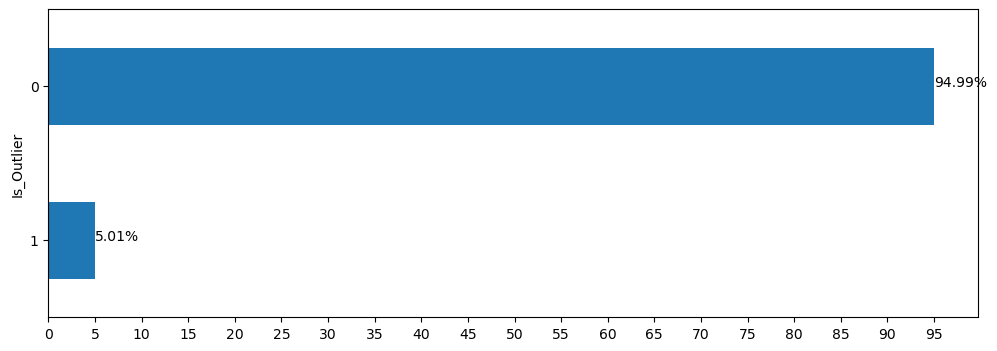

In [38]:
outlier_percentage = customer_data['Is_Outlier'].value_counts(normalize=True) * 100

plt.figure(figsize=(12, 4))
outlier_percentage.plot(kind='barh')

for index, value in enumerate(outlier_percentage):
    plt.text(value, index, f'{value:.2f}%')

plt.xticks(ticks=np.arange(0, 100, 5))
plt.gca().invert_yaxis()
plt.show()

In [39]:
outlier_data = customer_data[customer_data['Is_Outlier'] == 1]
customer_data_cleaned = customer_data[customer_data['Is_Outlier'] == 0]
customer_data_cleaned = customer_data_cleaned.drop(columns=['Outlier_Scores', 'Is_Outlier'])
customer_data_cleaned.reset_index(drop=True, inplace=True)

In [40]:
customer_data_cleaned

,Customer ID,Days_Since_Last_Purchase,Total_Transaction,Total_Product_Purchased,Total_Spend,Average_Transaction_Value,Unique_Product_Purchased,Average_Days_Between_Purchases,Favorite_Week,Favorite_Hour,Is_UK,Cancellation_Frequency,Cancellation_Rate,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend
0,12346.0,325,4,24,169.36,42.34,25,12.88,0,13,1,1,0.25,56.453333,75.574143,-13.525
1,12347.0,2,8,2967,4921.53,615.19125,126,1.819005,1,14,0,0,0.0,615.19125,315.773658,3.339405
2,12348.0,75,5,2704,1658.4,331.68,24,8.066667,0,14,0,0,0.0,331.68,187.058966,-22.812
3,12349.0,18,4,1616,3654.54,913.635,138,4.073864,3,9,0,1,0.25,913.635,647.144349,452.92
4,12350.0,310,1,196,294.4,294.4,16,0.0,2,16,0,0,0.0,294.4,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5474,18283.0,3,22,1677,2658.95,120.861364,351,0.700535,3,13,1,0,0.0,189.925,144.03184,12.74622
5475,18284.0,429,2,493,436.68,218.34,28,0.071429,0,11,1,1,0.5,436.68,0.0,0.0
5476,18285.0,660,1,145,427.0,427.0,12,0.0,2,10,1,0,0.0,427.0,0.0,0.0
5477,18286.0,476,3,592,1188.43,396.143333,67,3.57971,4,11,1,1,0.066667,396.143333,474.282084,185.265


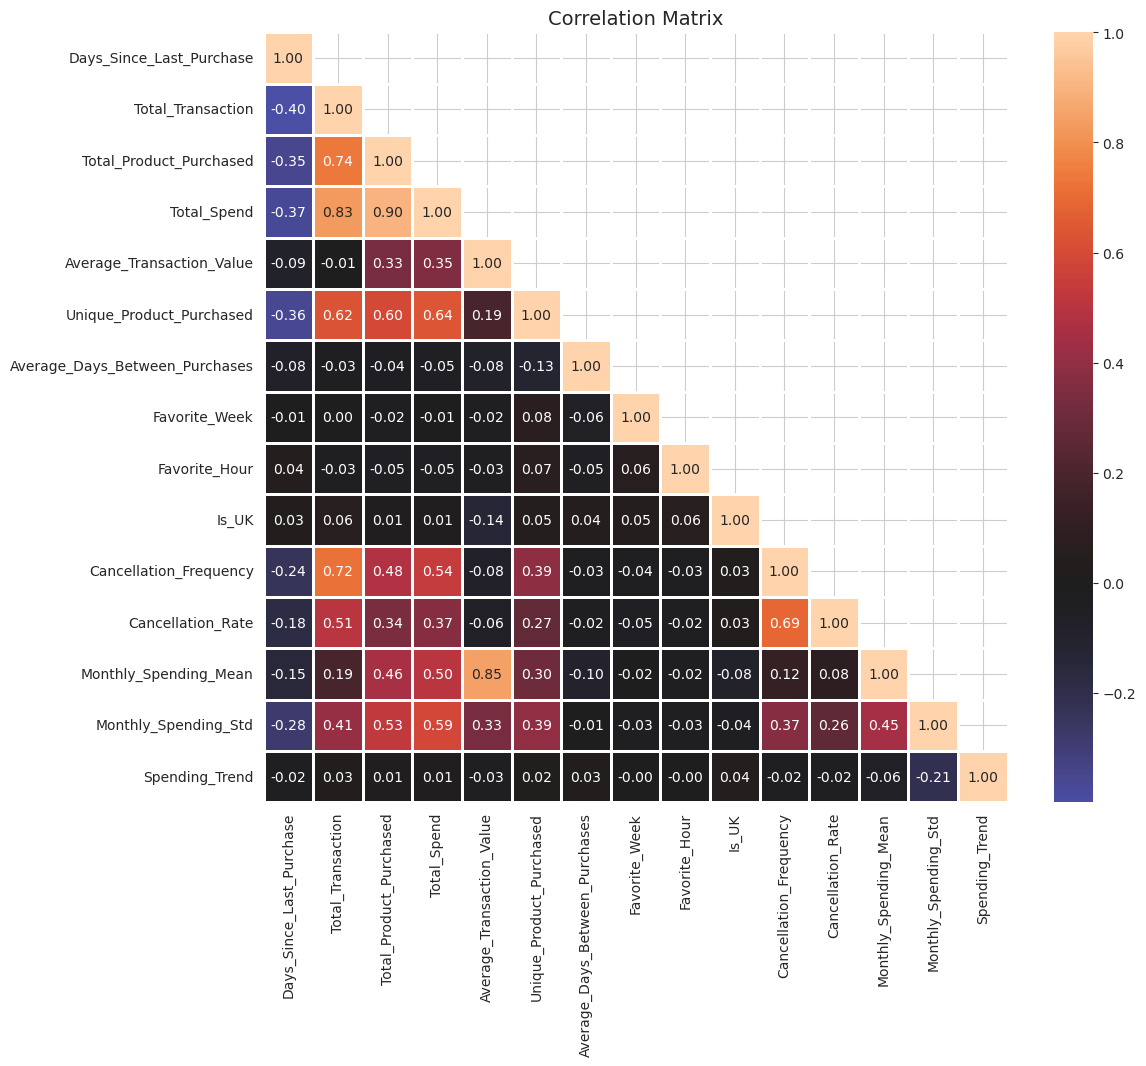

In [41]:
import seaborn as sns
sns.set_style('whitegrid')

corr = customer_data_cleaned.drop(columns=['Customer ID']).corr()

mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask, k=1)] = True

plt.figure(figsize=(12, 10))
sns.heatmap(corr, mask=mask, annot=True, center=0, fmt='.2f', linewidths=2)
plt.title('Correlation Matrix', fontsize=14)
plt.show()

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

columns_to_exclude = ['Customer ID', 'Is_UK', 'Favorite_Week']
columns_to_scale = customer_data_cleaned.columns.difference(columns_to_exclude)
customer_data_scaled = customer_data_cleaned.copy()

customer_data_scaled[columns_to_scale] = scaler.fit_transform(customer_data_scaled[columns_to_scale])

customer_data_scaled

,Customer ID,Days_Since_Last_Purchase,Total_Transaction,Total_Product_Purchased,Total_Spend,Average_Transaction_Value,Unique_Product_Purchased,Average_Days_Between_Purchases,Favorite_Week,Favorite_Hour,Is_UK,Cancellation_Frequency,Cancellation_Rate,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend
0,12346.0,0.598318,-0.274459,-0.691470,-0.674154,-1.172540,-0.576946,0.407656,0,0.188931,1,0.061948,-0.127004,-1.108045,-0.368650,0.051784
1,12347.0,-0.956108,0.348538,1.536660,1.625061,1.738161,0.637008,-0.192248,1,0.634350,0,-0.555170,-0.414258,1.044288,0.958621,0.154788
2,12348.0,-0.604798,-0.118709,1.337544,0.046280,0.297619,-0.588965,0.146600,0,0.634350,0,-0.555170,-0.414258,-0.047835,0.247382,-0.004939
3,12349.0,-0.879109,-0.274459,0.513825,1.012060,3.254577,0.781240,-0.069953,3,-1.592744,0,0.061948,-0.127004,2.193933,2.789677,2.900735
4,12350.0,0.526131,-0.741707,-0.561249,-0.613656,0.108196,-0.685120,-0.290903,2,1.525187,0,-0.555170,-0.414258,-0.191443,-0.786250,0.134392
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5474,18283.0,-0.951296,2.529028,0.560008,0.530370,-0.773567,3.341360,-0.252909,3,0.188931,1,-0.555170,-0.414258,-0.593895,0.009627,0.212243
5475,18284.0,1.098814,-0.585957,-0.336392,-0.544818,-0.278271,-0.540888,-0.287029,0,-0.701906,1,0.061948,0.160249,0.356639,-0.786250,0.134392
5476,18285.0,2.210494,-0.741707,-0.599861,-0.549501,0.781947,-0.733198,-0.290903,2,-1.147325,1,-0.555170,-0.414258,0.319350,-0.786250,0.134392
5477,18286.0,1.325000,-0.430208,-0.261440,-0.181103,0.625162,-0.072134,-0.096754,4,-0.701906,1,0.061948,-0.337657,0.200486,1.834492,1.265953


In [43]:
customer_data_scaled.set_index('Customer ID', inplace=True)

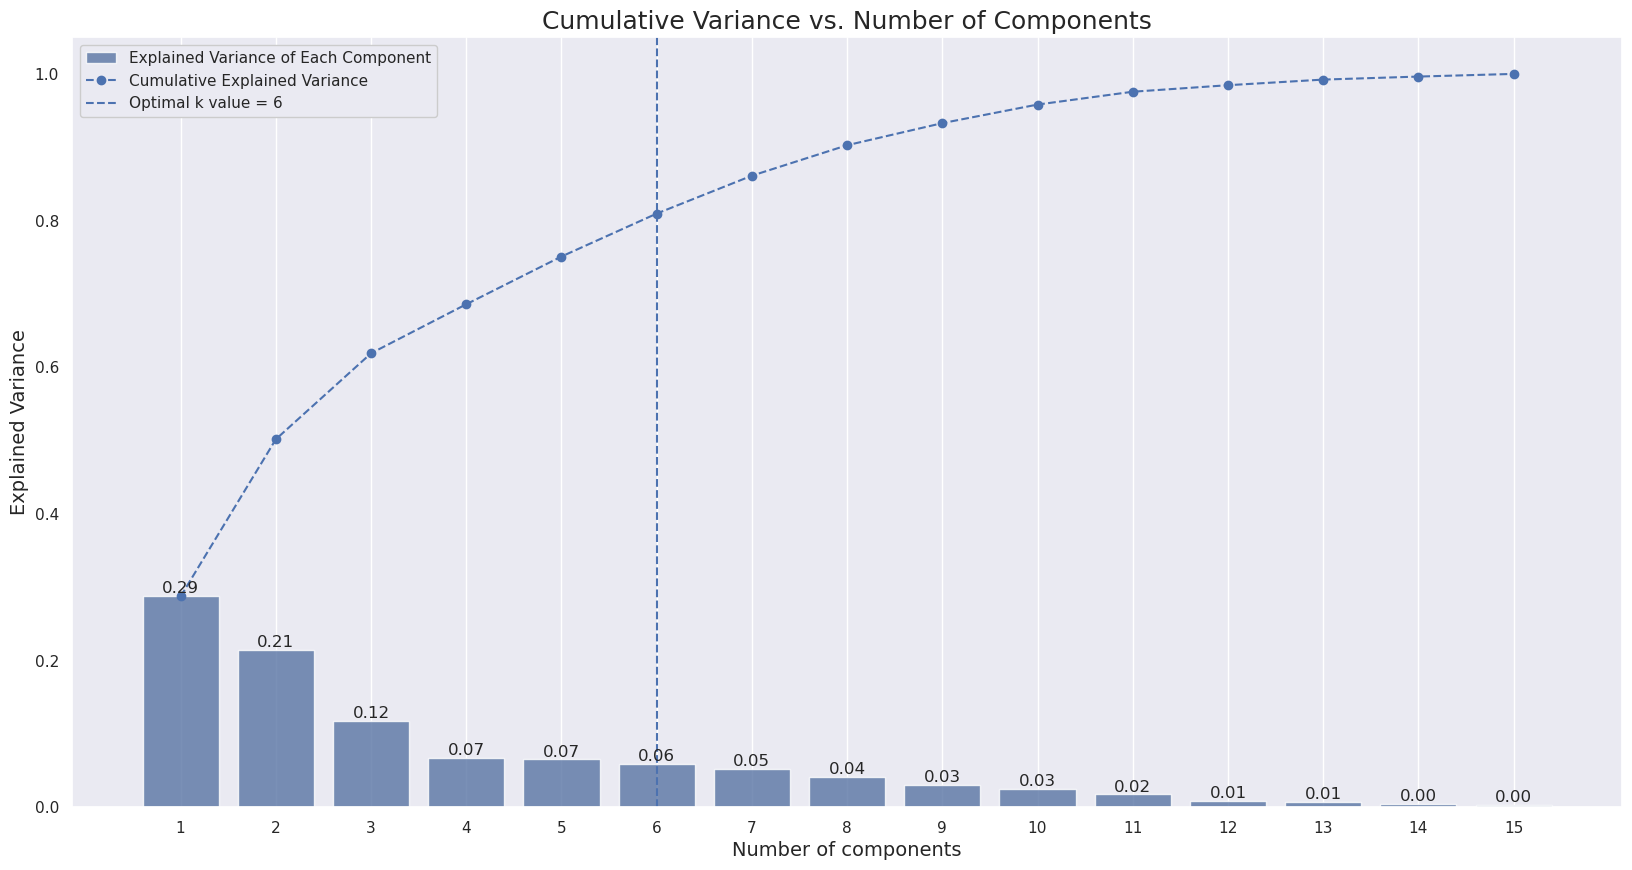

In [44]:
from sklearn.decomposition import PCA

pca = PCA().fit(customer_data_scaled)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

optimal_k = 6

sns.set(style='darkgrid')
plt.figure(figsize=(20, 10))

barplot = sns.barplot(x=list(range(1, len(cumulative_explained_variance) + 1)),
                      y=explained_variance_ratio,
                      alpha=0.8)

lineplot, = plt.plot(range(0, len(cumulative_explained_variance)), cumulative_explained_variance, marker='o', linestyle='--')
optimal_k_line = plt.axvline(optimal_k - 1, linestyle='--', label=f'Optimal k value = {optimal_k}')

plt.xlabel('Number of components', fontsize=14)
plt.ylabel('Explained Variance', fontsize=14)
plt.title('Cumulative Variance vs. Number of Components', fontsize=18)

plt.xticks(range(0, len(cumulative_explained_variance)))
plt.legend(handles=[barplot.patches[0], lineplot, optimal_k_line],
           labels=['Explained Variance of Each Component', 'Cumulative Explained Variance', f'Optimal k value = {optimal_k}'],
           frameon=True,
           framealpha=1.0,)

x_offset = -0.3
y_offset = 0.01

for i, (ev_ratio, cum_ev_ration) in enumerate(zip(explained_variance_ratio, cumulative_explained_variance)):
    plt.text(i, ev_ratio, f'{ev_ratio:.2f}', ha='center', va='bottom')

plt.grid(axis='both')
plt.show()

In [45]:
pca = PCA(n_components=6)

customer_data_pca = pca.fit_transform(customer_data_scaled)

customer_data_pca = pd.DataFrame(customer_data_pca, columns=['PC'+str(i+1) for i in range(pca.n_components_)])

customer_data_pca.index = customer_data_scaled.index

In [46]:
customer_data_pca

,PC1,PC2,PC3,PC4,PC5,PC6
Customer ID,,,,,,
12346.0,-1.520000,-2.633365,-1.299852,-0.171661,0.003718,0.281891
12347.0,2.488790,-1.433188,2.061244,0.457803,0.673495,0.846762
12348.0,0.363258,-2.558731,0.599175,0.279226,0.269506,0.904563
12349.0,2.909306,0.401529,3.423521,2.388018,0.460033,-1.612626
12350.0,-1.669020,-0.570697,0.408796,-0.621571,1.073367,0.773042
...,...,...,...,...,...,...
18283.0,2.174797,0.778729,-1.210742,0.695690,1.201677,1.042730
18284.0,-1.039376,-2.662322,0.045800,-0.325803,0.141642,-1.154686
18285.0,-1.743184,-0.725589,1.191509,-0.276506,-0.049559,-1.816321


In [47]:
def highlight_top3(column):
    top3 = column.abs().nlargest(3).index
    return ['background-color: green' if i in top3 else '' for i in column.index]

pca_df = pd.DataFrame(pca.components_.T, columns=['PC{}'.format(i+1) for i in range(pca.n_components_)],
                      index=customer_data_scaled.columns)

pca_df.style.apply(highlight_top3, axis=0)

,PC1,PC2,PC3,PC4,PC5,PC6
Days_Since_Last_Purchase,-0.219594,-0.019598,0.065685,-0.338131,0.098682,-0.318620
Total_Transaction,0.388331,0.023010,-0.264600,0.045137,0.059041,-0.001474
Total_Product_Purchased,0.401186,0.006856,0.042252,0.095537,0.054969,0.007043
Total_Spend,0.424979,0.015520,0.036100,0.077733,0.053736,-0.002709
Average_Transaction_Value,0.170253,-0.007646,0.605892,0.042452,0.029472,-0.088349
Unique_Product_Purchased,0.330026,0.068795,-0.023644,0.020716,0.220710,0.145535
Average_Days_Between_Purchases,-0.033600,-0.044493,-0.087464,0.539295,-0.473879,0.428927
Favorite_Week,-0.036636,0.994710,-0.000042,0.022334,-0.062856,-0.036037
Favorite_Hour,-0.021324,0.045578,-0.006795,-0.333793,0.492903,0.732844
Is_UK,-0.000071,0.007060,-0.025011,0.003056,0.014093,0.015250


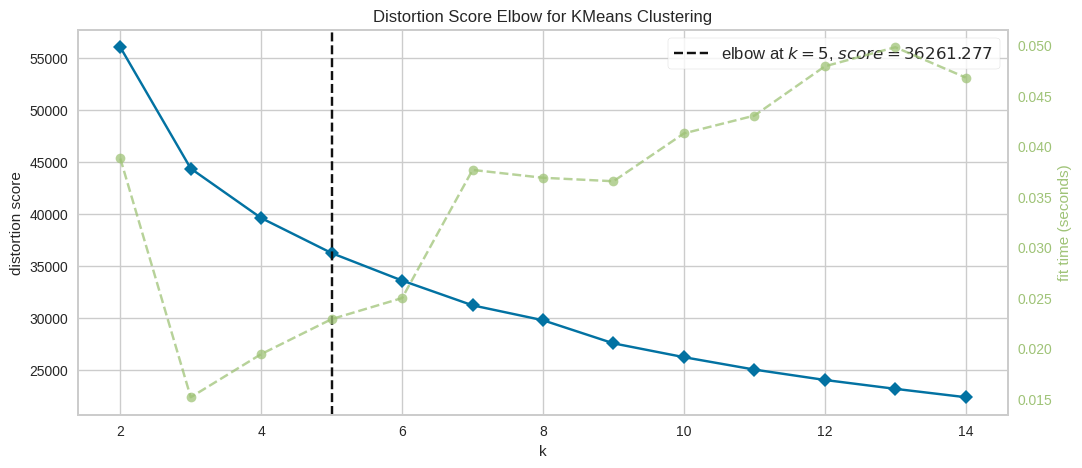

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [48]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

km = KMeans(init='k-means++', n_init=10, max_iter=100, random_state=0)

fig, ax = plt.subplots(figsize=(12, 5))
visualizer = KElbowVisualizer(km, k=(2, 15), timing=False, ax=ax)
visualizer.fit(customer_data_pca)
visualizer.show()

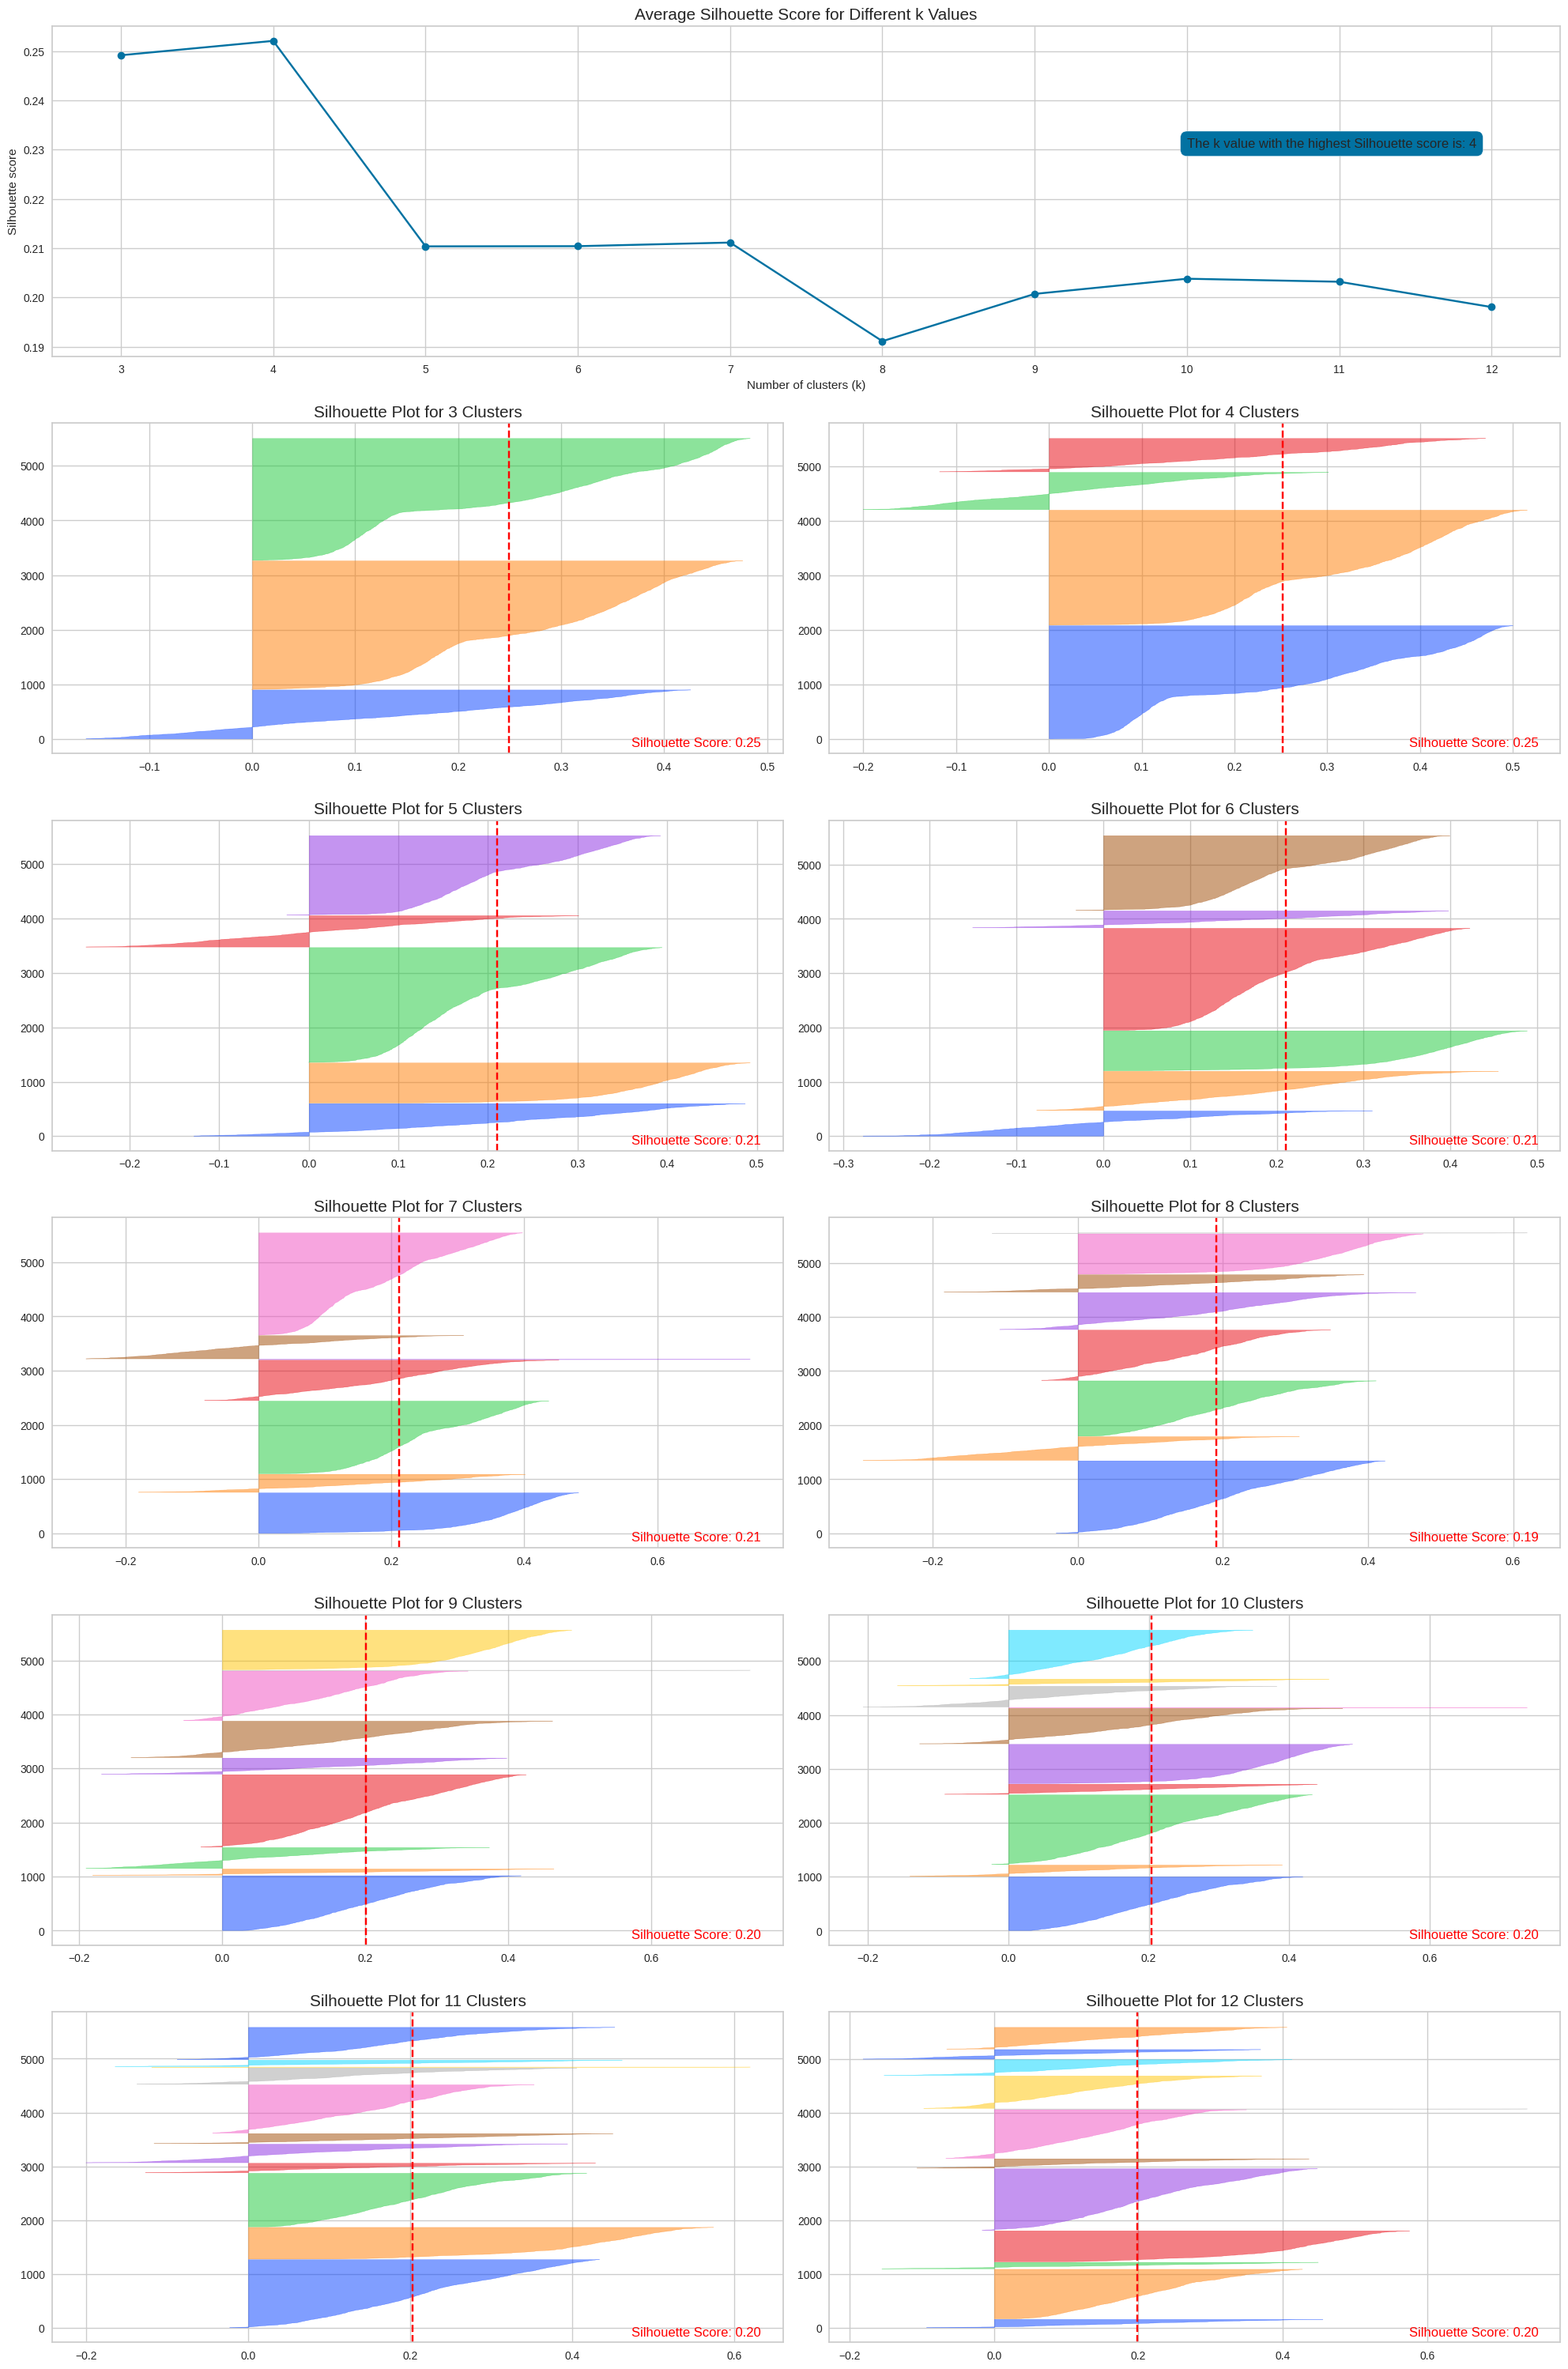

In [49]:
import matplotlib.gridspec as gridspec
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.metrics import silhouette_score

def silhouette_analysis(df, start_k, stop_k, figsize=(15, 16)):

    # Set the size of the figure
    plt.figure(figsize=figsize)

    # Create a grid with (stop_k - start_k + 1) rows and 2 columns
    grid = gridspec.GridSpec(stop_k - start_k + 1, 2)

    # Assign the first plot to the first row and both columns
    first_plot = plt.subplot(grid[0, :])

    # Iterate through the range of k values
    silhouette_scores = []
    for k in range(start_k, stop_k + 1):
        km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=100, random_state=0)
        km.fit(df)
        labels = km.predict(df)
        score = silhouette_score(df, labels)
        silhouette_scores.append(score)

    best_k = start_k + silhouette_scores.index(max(silhouette_scores))

    plt.plot(range(start_k, stop_k + 1), silhouette_scores, marker='o')
    plt.xticks(range(start_k, stop_k + 1))
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Silhouette score')
    plt.title('Average Silhouette Score for Different k Values', fontsize=15)

    # Add the optimal k value text to the plot
    optimal_k_text = f'The k value with the highest Silhouette score is: {best_k}'
    plt.text(10, 0.23, optimal_k_text, fontsize=12, verticalalignment='bottom', 
             horizontalalignment='left', bbox=dict(boxstyle='round, pad=0.5'))

    # Second plot (subplot): Silhouette plots for each k value
    colors = sns.color_palette("bright")
    for i in range(start_k, stop_k + 1):    
        km = KMeans(n_clusters=i, init='k-means++', n_init=10, max_iter=100, random_state=0)
        row_idx, col_idx = divmod(i - start_k, 2)

        # Assign the plots to the second, third, and fourth rows
        ax = plt.subplot(grid[row_idx + 1, col_idx])

        visualizer = SilhouetteVisualizer(km, colors=colors, ax=ax)
        visualizer.fit(df)

        # Add the Silhouette score text to the plot
        score = silhouette_score(df, km.labels_)
        ax.text(0.97, 0.02, f'Silhouette Score: {score:.2f}', fontsize=12, \
                ha='right', transform=ax.transAxes, color='red')

        ax.set_title(f'Silhouette Plot for {i} Clusters', fontsize=15)

    plt.tight_layout()
    plt.show()

silhouette_analysis(customer_data_pca, 3, 12, figsize=(20, 50))

In [50]:
from collections import Counter

kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, max_iter=100, random_state=0)
kmeans.fit(customer_data_pca)

cluster_frequencies = Counter(kmeans.labels_)

label_mapping = {label: new_label for new_label, (label, _) in enumerate(cluster_frequencies.most_common())}
label_mapping = {v:k for k, v in {2:1, 1:0, 0:2}.items()}
new_labels = np.array([label_mapping[label] for label in kmeans.labels_]) 

customer_data_cleaned['cluster'] = new_labels
customer_data_pca['cluster'] = new_labels

In [51]:
customer_data_cleaned.head()

,Customer ID,Days_Since_Last_Purchase,Total_Transaction,Total_Product_Purchased,Total_Spend,Average_Transaction_Value,Unique_Product_Purchased,Average_Days_Between_Purchases,Favorite_Week,Favorite_Hour,Is_UK,Cancellation_Frequency,Cancellation_Rate,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend,cluster
0,12346.0,325,4,24,169.36,42.34,25,12.88,0,13,1,1,0.25,56.453333,75.574143,-13.525,2
1,12347.0,2,8,2967,4921.53,615.19125,126,1.819005,1,14,0,0,0.0,615.19125,315.773658,3.339405,1
2,12348.0,75,5,2704,1658.4,331.68,24,8.066667,0,14,0,0,0.0,331.68,187.058966,-22.812,2
3,12349.0,18,4,1616,3654.54,913.635,138,4.073864,3,9,0,1,0.25,913.635,647.144349,452.92,1
4,12350.0,310,1,196,294.4,294.4,16,0.0,2,16,0,0,0.0,294.4,0.0,0.0,2


In [52]:
import plotly.graph_objects as go

cluster_0 = customer_data_pca[customer_data_pca['cluster'] == 0] 
cluster_1 = customer_data_pca[customer_data_pca['cluster'] == 1]
cluster_2 = customer_data_pca[customer_data_pca['cluster'] == 2]

fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=cluster_0['PC1'], y=cluster_0['PC2'], z=cluster_0['PC3'],
    mode='markers', marker=dict(size=4), name='Cluster 0'
))
fig.add_trace(go.Scatter3d(
    x=cluster_1['PC1'], y=cluster_1['PC2'], z=cluster_1['PC3'],
    mode='markers', marker=dict(size=4), name='Cluster 1'
))
fig.add_trace(go.Scatter3d(
    x=cluster_2['PC1'], y=cluster_2['PC2'], z=cluster_2['PC3'],
    mode='markers', marker=dict(size=4), name='Cluster 2'
))

fig.update_layout(
    title=dict(text='3D Visualization of Customer Clusters in PCA Space', x=0.5),
    scene=dict(
        xaxis=dict(backgroundcolor="#fcf0dc", gridcolor='white', title='PC1'),
        yaxis=dict(backgroundcolor="#fcf0dc", gridcolor='white', title='PC2'),
        zaxis=dict(backgroundcolor="#fcf0dc", gridcolor='white', title='PC3'),
    ),
    width=900,
    height=800
)
fig.show()

/tmp/ipykernel_13767/930690426.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_13767/930690426.py:7: UserWarning:

The palette list has more values (10) than needed (3), which may not be intended.



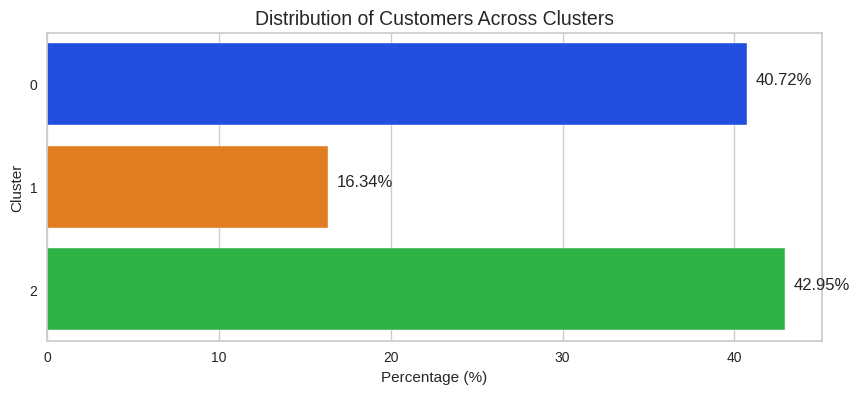

In [53]:
cluster_percentage = (customer_data_pca['cluster'].value_counts(normalize=True) * 100).reset_index()
cluster_percentage.columns = ['Cluster', 'Percentage']
cluster_percentage.sort_values(by='Cluster', inplace=True)

plt.figure(figsize=(10, 4))
colors = sns.color_palette("bright")
sns.barplot(x='Percentage', y='Cluster', data=cluster_percentage, orient='h', palette=colors, legend=False)

for index, value in enumerate(cluster_percentage['Percentage']):
    plt.text(value+0.5, index, f'{value:.2f}%')

plt.title('Distribution of Customers Across Clusters', fontsize=14)
plt.xlabel('Percentage (%)')

plt.show()

In [54]:
from tabulate import tabulate
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

# Compute number of customers
num_observations = len(customer_data_pca)

# Separate the features and the cluster labels
X = customer_data_pca.drop('cluster', axis=1)
clusters = customer_data_pca['cluster']

# Compute the metrics
sil_score = silhouette_score(X, clusters)
calinski_score = calinski_harabasz_score(X, clusters)
davies_score = davies_bouldin_score(X, clusters)

# Create a table to display the metrics and the number of observations
table_data = [
    ["Number of Observations", num_observations],
    ["Silhouette Score", sil_score],
    ["Calinski Harabasz Score", calinski_score],
    ["Davies Bouldin Score", davies_score]
]

# Print the table
print(tabulate(table_data, headers=["Metric", "Value"], tablefmt='pretty'))

+-------------------------+---------------------+
|         Metric          |        Value        |
+-------------------------+---------------------+
| Number of Observations  |        5479         |
|    Silhouette Score     | 0.24915346696793503 |
| Calinski Harabasz Score | 1805.1284262460517  |
|  Davies Bouldin Score   | 1.3308793142804887  |
+-------------------------+---------------------+


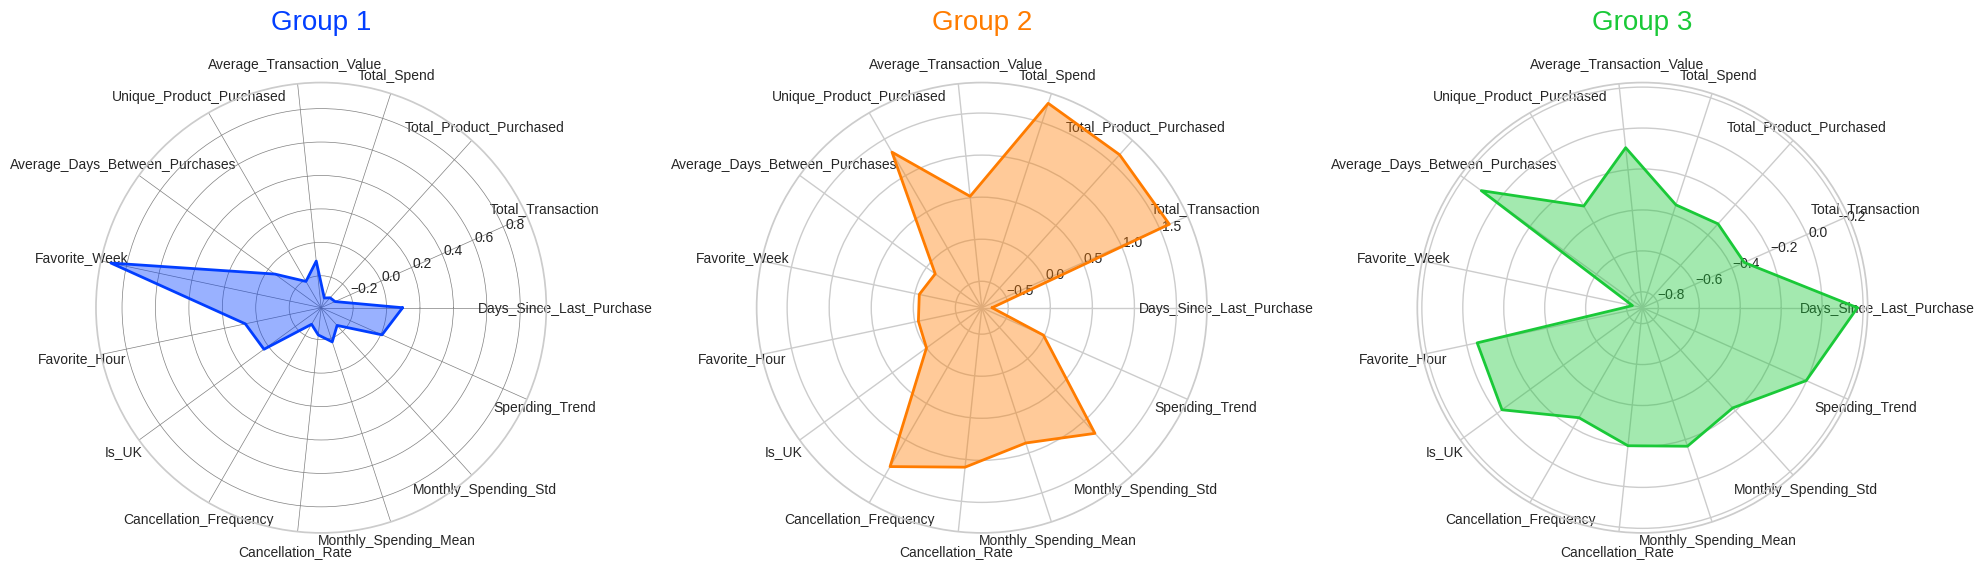

In [55]:
# Setting 'CustomerID' column as index and assigning it to a new dataframe
df_customer = customer_data_cleaned.set_index('Customer ID')

# Standardize the data (excluding the cluster column)
scaler = StandardScaler()
df_customer_standardized = scaler.fit_transform(df_customer.drop(columns=['cluster'], axis=1))

# Create a new dataframe with standardized values and add the cluster column back
df_customer_standardized = pd.DataFrame(df_customer_standardized, columns=df_customer.columns[:-1], index=df_customer.index)
df_customer_standardized['cluster'] = df_customer['cluster']

# Calculate the centroids of each cluster
cluster_centroids = df_customer_standardized.groupby('cluster').mean()

# Function to create a radar chart
def create_radar_chart(ax, angles, data, color, cluster):
    # Plot the data and fill the area
    ax.fill(angles, data, color=color, alpha=0.4)
    ax.plot(angles, data, color=color, linewidth=2, linestyle='solid')
    
    # Add a title
    ax.set_title(f'Group {cluster+1}', size=20, color=color, y=1.1)

# Set data
labels = np.array(cluster_centroids.columns)
num_vars = len(labels)

# Compute angle of each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# The plot is circular, so we need to "complete the loop" and append the start to the end
labels = np.concatenate((labels, [labels[0]]))
angles += angles[:1]

# Initialize the figure
fig, ax = plt.subplots(figsize=(20, 10), subplot_kw=dict(polar=True), nrows=1, ncols=3)

# Create radar chart for each cluster
for i, (cluster_id, color) in enumerate(zip(cluster_centroids.index, colors)):
    data = cluster_centroids.loc[cluster_id].tolist()
    data += data[:1]  # Complete the loop
    create_radar_chart(ax[i], angles, data, color, cluster_id)

# Add input data
ax[0].set_xticks(angles[:-1])
ax[0].set_xticklabels(labels[:-1])

ax[1].set_xticks(angles[:-1])
ax[1].set_xticklabels(labels[:-1])

ax[2].set_xticks(angles[:-1])
ax[2].set_xticklabels(labels[:-1])

# Add a grid
ax[0].grid(color='grey', linewidth=0.5)

# Display the plot
plt.tight_layout()
plt.show()

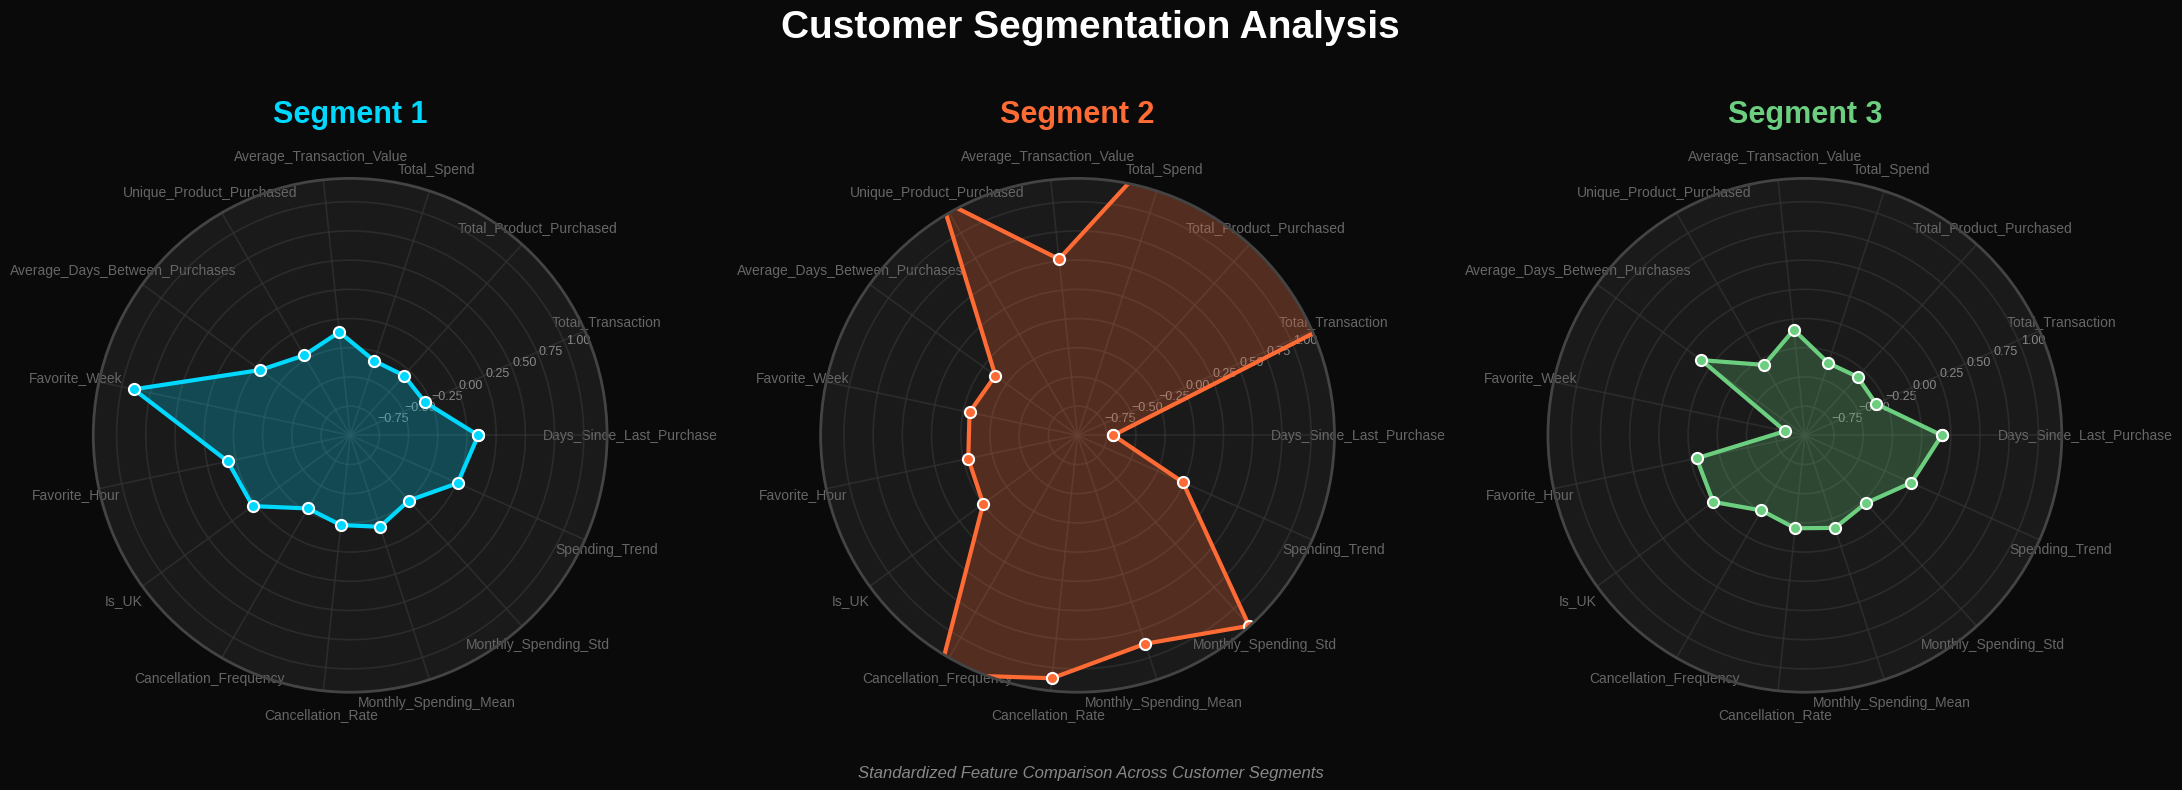

In [56]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager

# Set dark theme style
plt.style.use('dark_background')

# Professional color palette
colors = ['#00D9FF', '#FF6B35', '#6BCF7F']  # Cyan, Orange, Green

# Set data
labels = np.array(cluster_centroids.columns)
num_vars = len(labels)

# Compute angles
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
labels = np.concatenate((labels, [labels[0]]))
angles += angles[:1]

# Create figure with dark background
fig = plt.figure(figsize=(22, 8), facecolor='#0a0a0a')
fig.suptitle('Customer Segmentation Analysis', fontsize=28, fontweight='bold', 
             color='white', y=0.98, fontfamily='sans-serif')

# Create subplots
ax = [plt.subplot(1, 3, i+1, projection='polar', facecolor='#1a1a1a') for i in range(3)]

def create_radar_chart(axis, angles, data, color, cluster):
    # Plot filled area with glow effect
    axis.fill(angles, data, color=color, alpha=0.25)
    axis.plot(angles, data, color=color, linewidth=3, linestyle='solid')
    axis.plot(angles, data, 'o', color=color, markersize=8, markeredgecolor='white', 
              markeredgewidth=1.5)
    
    # Title styling
    axis.set_title(f'Segment {cluster+1}', size=22, color=color, 
                   pad=20, fontweight='bold', fontfamily='sans-serif')

# Plot each cluster
for i, (cluster_id, color) in enumerate(zip(cluster_centroids.index, colors)):
    data = cluster_centroids.loc[cluster_id].tolist()
    data += data[:1]
    create_radar_chart(ax[i], angles, data, color, cluster_id)
    
    # Styling for each subplot
    ax[i].set_xticks(angles[:-1])
    ax[i].set_xticklabels(labels[:-1], size=10, color='#cccccc', fontweight='500')
    ax[i].tick_params(colors='#666666', pad=10)
    ax[i].grid(color='#333333', linewidth=1.2, linestyle='-', alpha=0.7)
    ax[i].set_ylim(-1, 1.2)
    
    # Radial labels styling
    ax[i].tick_params(axis='y', labelsize=9, colors='#888888')
    ax[i].spines['polar'].set_color('#444444')
    ax[i].spines['polar'].set_linewidth(2)

# Add subtitle/description
fig.text(0.5, 0.02, 'Standardized Feature Comparison Across Customer Segments', 
         ha='center', fontsize=12, color='#888888', style='italic')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

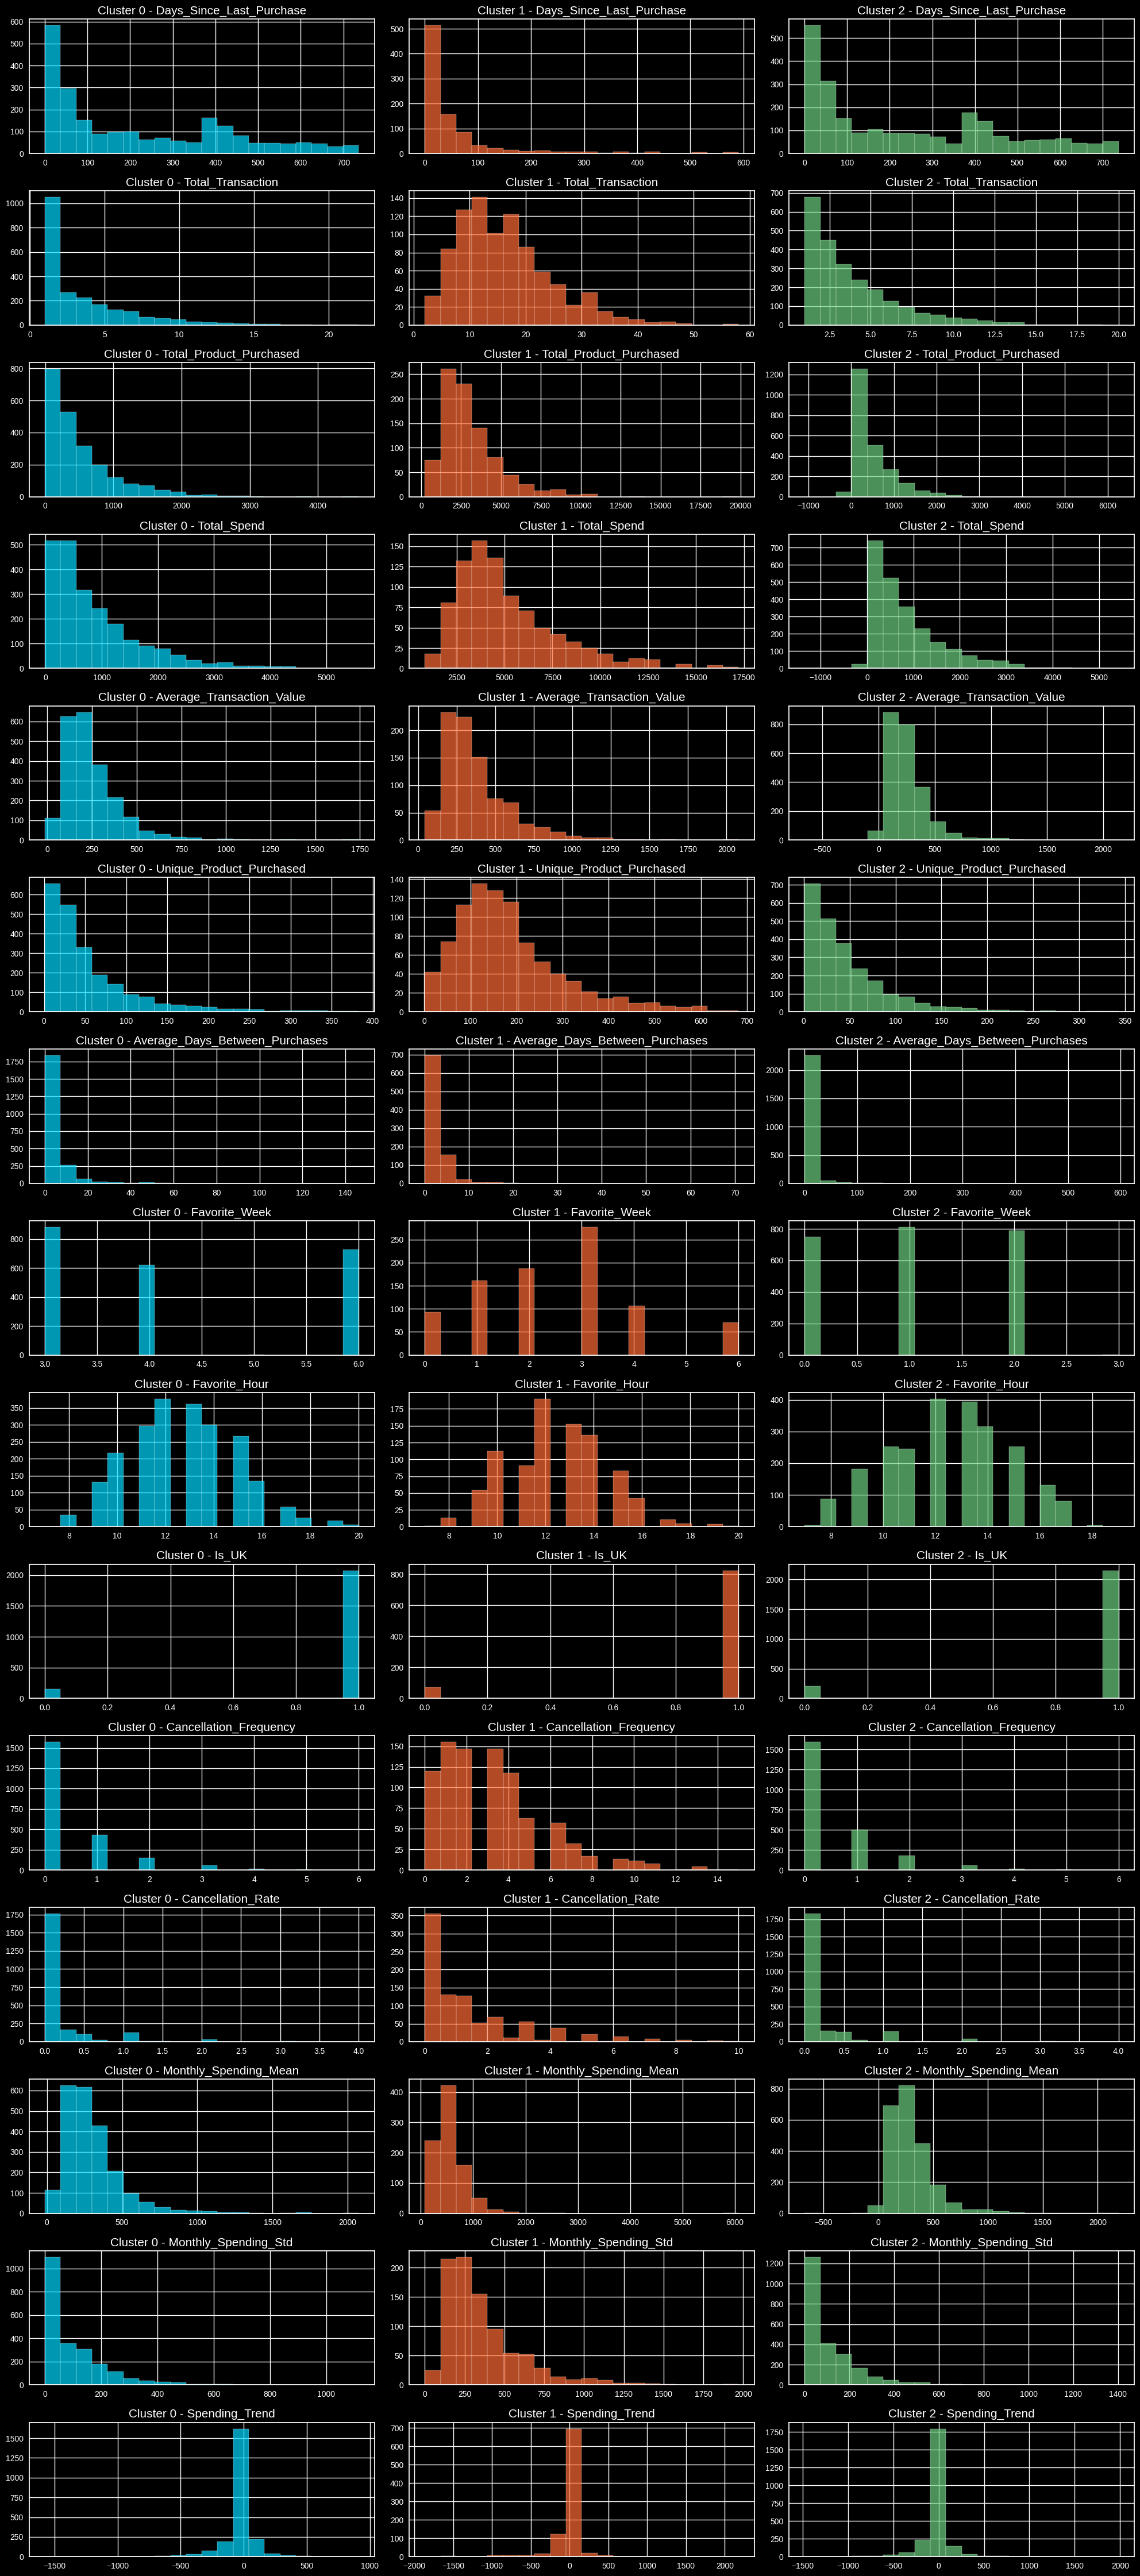

In [57]:
# Plot histograms for each feature segmented by the clusters
features = customer_data_cleaned.columns[1:-1]
clusters = customer_data_cleaned['cluster'].unique()
clusters.sort()

# Setting up the subplots
n_rows = len(features)
n_cols = len(clusters)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3*n_rows))

# Plotting histograms
for i, feature in enumerate(features):
    for j, cluster in enumerate(clusters):
        data = customer_data_cleaned[customer_data_cleaned['cluster'] == cluster][feature]
        axes[i, j].hist(data, bins=20, color=colors[j], edgecolor='w', alpha=0.7)
        axes[i, j].set_title(f'Cluster {cluster} - {feature}', fontsize=15)
        axes[i, j].set_xlabel('')
        axes[i, j].set_ylabel('')

# Adjusting layout to prevent overlapping
plt.tight_layout()
plt.show()

In [58]:
outlier_customer_ids = outlier_data['Customer ID'].astype(float).unique()
retail_filtered = retail[~retail['Customer ID'].isin(outlier_customer_ids)]
customer_data_cleaned['Customer ID'] = customer_data_cleaned[['Customer ID']].astype(float)

merged_data = retail_filtered.merge(customer_data_cleaned[['Customer ID', 'cluster']], on='Customer ID', how='inner')

In [59]:
best_selling_products = merged_data.groupby(['cluster', 'StockCode', 'Description'])['Quantity'].sum().reset_index()
best_selling_products = best_selling_products.sort_values(by=['cluster', 'Quantity'], ascending=[True, False])
top_products_per_cluster = best_selling_products.groupby('cluster').head(10)
customer_purchases = merged_data.groupby(['Customer ID', 'cluster', 'StockCode'])['Quantity'].sum().reset_index()

In [60]:
recommendation = []
for cluster in top_products_per_cluster['cluster'].unique():
    top_products = top_products_per_cluster[top_products_per_cluster['cluster'] == cluster]
    customers_in_cluster = customer_data_cleaned[customer_data_cleaned['cluster'] == cluster]['Customer ID']
    
    for customer in customers_in_cluster:
        customer_purchased_products = customer_purchases[(customer_purchases['Customer ID'] == customer) & (customer_purchases['cluster'] == cluster)]['StockCode'].tolist()
        top_products_not_purchased = top_products[~top_products['StockCode'].isin(customer_purchased_products)]
        top_3_products_not_purchased = top_products_not_purchased.head(3)
        recommendation.append([customer, cluster] + top_3_products_not_purchased[['StockCode', 'Description']].values.flatten().tolist())

In [61]:
recommendation_data = pd.DataFrame(recommendation, columns=['Customer ID', 'cluster', 'Rec1_StockCode', 'Rec1_Description','Rec2_StockCode', 'Rec2_Description','Rec3_StockCode', 'Rec3_Description', ])
customer_data_with_recommendation = customer_data_cleaned.merge(recommendation_data, on=['Customer ID', 'cluster'], how='right')

In [62]:
customer_data_with_recommendation

,Customer ID,Days_Since_Last_Purchase,Total_Transaction,Total_Product_Purchased,Total_Spend,Average_Transaction_Value,Unique_Product_Purchased,Average_Days_Between_Purchases,Favorite_Week,Favorite_Hour,...,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend,cluster,Rec1_StockCode,Rec1_Description,Rec2_StockCode,Rec2_Description,Rec3_StockCode,Rec3_Description
0,12354.0,232,1,530,1079.4,1079.4,58,0.0,3,13,...,1079.4,0.0,0.0,0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,84879,ASSORTED COLOUR BIRD ORNAMENT
1,12355.0,214,2,543,947.61,473.805,35,10.382353,4,11,...,473.805,20.371746,-28.81,0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,84879,ASSORTED COLOUR BIRD ORNAMENT
2,12361.0,287,4,231,451.25,112.8125,17,16.458333,4,15,...,112.8125,41.920289,25.795,0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,84879,ASSORTED COLOUR BIRD ORNAMENT
3,12364.0,7,4,1499,1208.1,302.025,69,1.3125,4,15,...,302.025,211.406551,-64.654,0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,84879,ASSORTED COLOUR BIRD ORNAMENT
4,12368.0,628,1,330,917.7,917.7,18,0.0,6,15,...,917.7,0.0,0.0,0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,84879,ASSORTED COLOUR BIRD ORNAMENT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5474,18277.0,58,7,445,1159.35,165.621429,53,6.606061,1,15,...,231.87,179.363689,-89.559,2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,17003,BROCADE RING PURSE,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS
5475,18280.0,277,3,192,472.45,157.483333,28,3.774194,2,15,...,236.225,78.665629,-111.25,2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,17003,BROCADE RING PURSE,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS
5476,18281.0,180,2,146,201.14,100.57,17,24.8125,1,10,...,100.57,27.930718,-39.5,2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,17003,BROCADE RING PURSE,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS
5477,18284.0,429,2,493,436.68,218.34,28,0.071429,0,11,...,436.68,0.0,0.0,2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,17003,BROCADE RING PURSE,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS


In [63]:
customer_data_with_recommendation.set_index('Customer ID').iloc[:, -6:].sample(10, random_state=0)

,Rec1_StockCode,Rec1_Description,Rec2_StockCode,Rec2_Description,Rec3_StockCode,Rec3_Description
Customer ID,,,,,,
16100.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,15036,ASSORTED COLOURS SILK FAN
12489.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,84879,ASSORTED COLOUR BIRD ORNAMENT
12400.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,84879,ASSORTED COLOUR BIRD ORNAMENT
14830.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,17003,BROCADE RING PURSE,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS
12383.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,17003,BROCADE RING PURSE,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS
12632.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,17003,BROCADE RING PURSE,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS
12486.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,17003,BROCADE RING PURSE,84879,ASSORTED COLOUR BIRD ORNAMENT
16453.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,17003,BROCADE RING PURSE,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS
13279.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,84879,ASSORTED COLOUR BIRD ORNAMENT


=== Recommendation System Metrics ===
----------------------------------------
Total Customers: 5479
Unique Products in Rec1: 8
Unique Products in Rec2: 10
Unique Products in Rec3: 13
Total Unique Products Recommended: 15


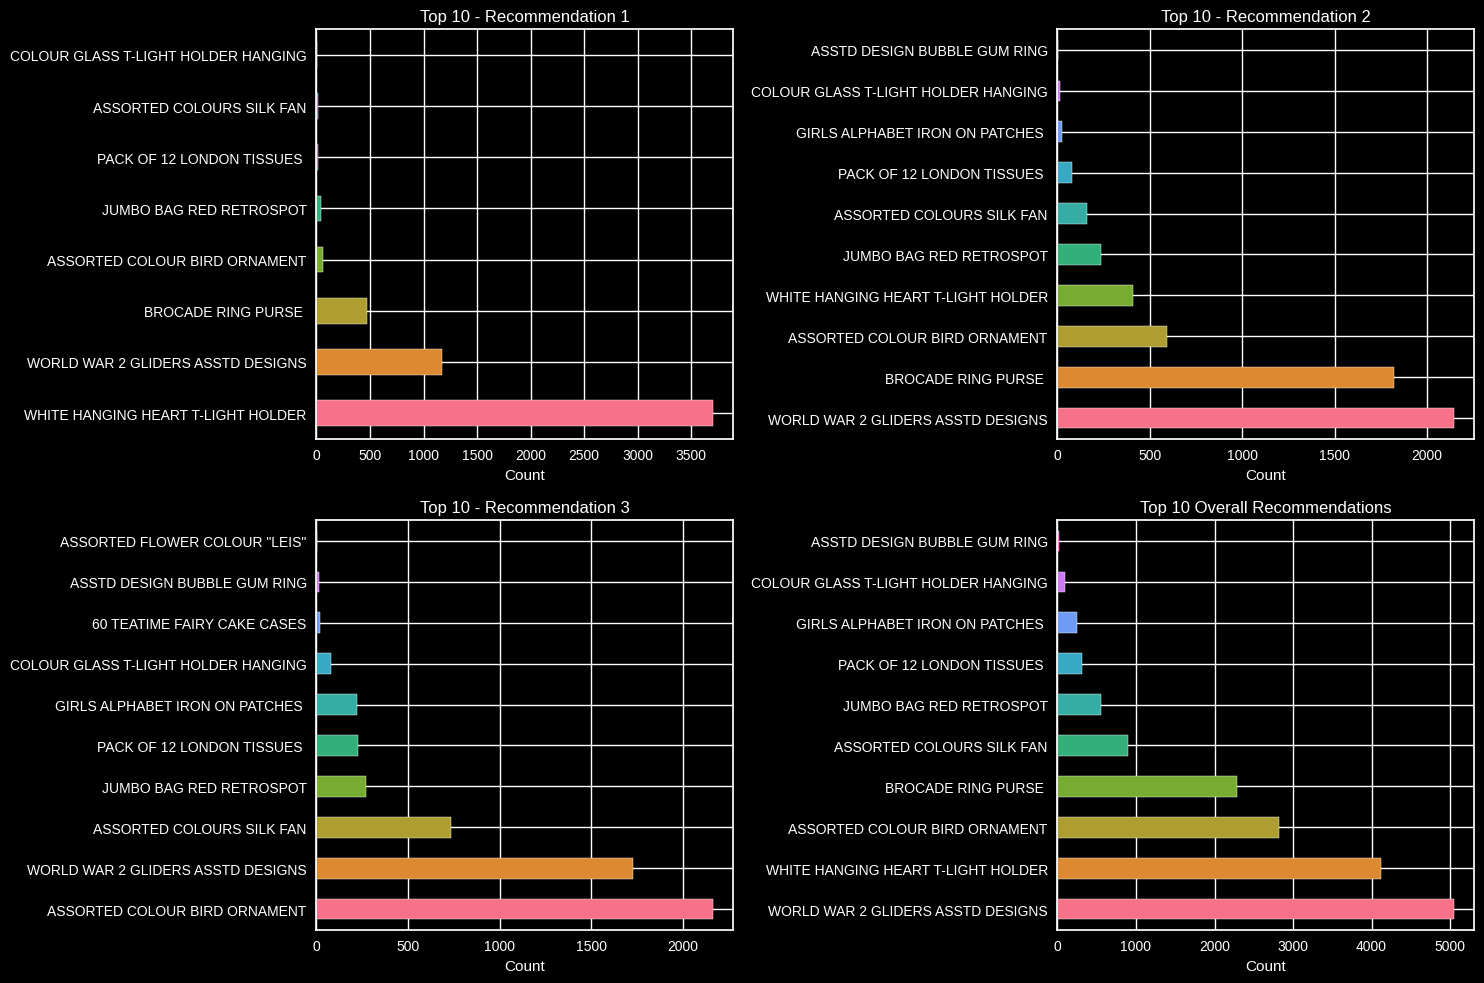

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Your data
rec_data = customer_data_with_recommendation.set_index('Customer ID').iloc[:, -6:]

# Summary Statistics
print("=== Recommendation System Metrics ===")
print("-"*40)
print(f"Total Customers: {len(rec_data)}")
print(f"Unique Products in Rec1: {rec_data['Rec1_Description'].nunique()}")
print(f"Unique Products in Rec2: {rec_data['Rec2_Description'].nunique()}")
print(f"Unique Products in Rec3: {rec_data['Rec3_Description'].nunique()}")

# Count recommendations by position
rec1_counts = rec_data['Rec1_Description'].value_counts().head(10)
rec2_counts = rec_data['Rec2_Description'].value_counts().head(10)
rec3_counts = rec_data['Rec3_Description'].value_counts().head(10)

# 2. Overall most recommended products
all_recs = pd.concat([
    rec_data['Rec1_Description'],
    rec_data['Rec2_Description'],
    rec_data['Rec3_Description']
])
top_overall = all_recs.value_counts().head(10)
print(f"Total Unique Products Recommended: {all_recs.nunique()}")

# 1. Recommendation Distribution by Position
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Set color palette
colors = sns.color_palette('husl', 10)

# Plot each position with colors
rec1_counts.plot(kind='barh', ax=axes[0, 0], title='Top 10 - Recommendation 1', color=colors)
axes[0, 0].set_xlabel('Count')
axes[0, 0].set_ylabel('')  # Remove ylabel

rec2_counts.plot(kind='barh', ax=axes[0, 1], title='Top 10 - Recommendation 2', color=colors)
axes[0, 1].set_xlabel('Count')
axes[0, 1].set_ylabel('')  # Remove ylabel

rec3_counts.plot(kind='barh', ax=axes[1, 0], title='Top 10 - Recommendation 3', color=colors)
axes[1, 0].set_xlabel('Count')
axes[1, 0].set_ylabel('')  # Remove ylabel

top_overall.plot(kind='barh', ax=axes[1, 1], title='Top 10 Overall Recommendations', color=colors)
axes[1, 1].set_xlabel('Count')
axes[1, 1].set_ylabel('')  # Remove ylabel

plt.tight_layout()
plt.savefig('recommendation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()